# Developing a Sentiment-Based Trading Strategy Using Natural Language Processing

Data Link : https://www.kaggle.com/datasets/equinxx/stock-tweets-for-sentiment-analysis-and-prediction?resource=download

In [1]:
import pandas as pd 
import numpy as np 
from datetime import datetime, timedelta
import yfinance as yf 
from textblob import TextBlob 
import re 
import matplotlib.pyplot as plt 
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid') 
from talib import EMA, RSI, OBV 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn import metrics, tree
from sklearn.preprocessing import StandardScaler 
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore') 

In [2]:
data = pd.read_csv('stock_tweets.csv') 
data.head() 

,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."


In [3]:
data.tail() 

,Date,Tweet,Stock Name,Company Name
80788,2021-10-07 17:11:57+00:00,Some of the fastest growing tech stocks on the...,XPEV,XPeng Inc.
80789,2021-10-04 17:05:59+00:00,"With earnings on the horizon, here is a quick ...",XPEV,XPeng Inc.
80790,2021-10-01 04:43:41+00:00,Our record delivery results are a testimony of...,XPEV,XPeng Inc.
80791,2021-10-01 00:03:32+00:00,"We delivered 10,412 Smart EVs in Sep 2021, rea...",XPEV,XPeng Inc.
80792,2021-09-30 10:22:52+00:00,Why can XPeng P5 deliver outstanding performan...,XPEV,XPeng Inc.


In [4]:
data['Stock Name'].nunique() 

25

In [5]:
data['Stock Name'].value_counts() 

Stock Name
TSLA    37422
TSM     11034
AAPL     5056
PG       4089
AMZN     4089
MSFT     4089
NIO      3021
META     2751
AMD      2227
NFLX     1727
GOOG     1291
PYPL      843
DIS       635
BA        399
COST      393
INTC      315
KO        310
CRM       233
XPEV      225
ENPH      216
ZS        193
VZ        123
BX         50
NOC        31
F          31
Name: count, dtype: int64

In [6]:
tsla_df = data[data['Stock Name']=='TSLA'] 
tsla_df.head() 

,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."


In [7]:
tsla_df = tsla_df.drop(columns=['Stock Name','Company Name']) 
tsla_df.head() 

,Date,Tweet
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,..."


In [8]:
print('First date : ',tsla_df['Date'].min())
print('Last date : ',tsla_df['Date'].max()) 

First date :  2021-09-30 01:16:13+00:00
Last date :  2022-09-29 23:41:16+00:00


In [9]:
tsla_df['Date'] = pd.to_datetime(tsla_df['Date']) 

### Clearing Tweets and Getting Sentiment

In [10]:
tsla_df['Clean_tweets'] = tsla_df['Tweet'].apply(lambda row: ' '.join(re.sub("(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)", " ",row).split())) 

In [11]:
tsla_df.head() 

,Date,Tweet,Clean_tweets
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,Mainstream media has done an amazing job at br...
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,Tesla delivery estimates are at around 364k fr...
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,3 Even if I include 63 0M unvested RSUs as of ...
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,Hahaha why are you still trying to stop Tesla ...
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",Stop trying to kill kids you sad deranged old man


In [12]:
tsla_df['tweet_sentiment'] = tsla_df['Clean_tweets'].apply(lambda row: 1 if TextBlob(row).sentiment.polarity>0 else (0 if TextBlob(row).sentiment.polarity==0 else -1))

In [13]:
tsla_df.head() 

,Date,Tweet,Clean_tweets,tweet_sentiment
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,Mainstream media has done an amazing job at br...,1
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,Tesla delivery estimates are at around 364k fr...,0
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,3 Even if I include 63 0M unvested RSUs as of ...,1
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,Hahaha why are you still trying to stop Tesla ...,1
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",Stop trying to kill kids you sad deranged old man,-1


Converting Date Column as DatetimeIndex 

In [14]:
tsla_df['Date'] = pd.to_datetime(tsla_df['Date'])
tsla_df.set_index('Date', inplace=True)

In [15]:
tweets_indicator_df =tsla_df.resample('D').tweet_sentiment.mean()

In [16]:
tweets_indicator_df.head() 

Date
2021-09-30 00:00:00+00:00    0.400000
2021-10-01 00:00:00+00:00    0.276596
2021-10-02 00:00:00+00:00    0.362069
2021-10-03 00:00:00+00:00    0.442623
2021-10-04 00:00:00+00:00    0.218487
Freq: D, Name: tweet_sentiment, dtype: float64

In [17]:
tweets_indicator_df.tail() 

Date
2022-09-25 00:00:00+00:00    0.527778
2022-09-26 00:00:00+00:00    0.430556
2022-09-27 00:00:00+00:00    0.294118
2022-09-28 00:00:00+00:00    0.373333
2022-09-29 00:00:00+00:00    0.294643
Freq: D, Name: tweet_sentiment, dtype: float64

### Cleaning Date column to remove time part 

In [18]:
tweets_indicator_df=tweets_indicator_df.tz_localize(None)

In [19]:
tweets_indicator_df.head() 

Date
2021-09-30    0.400000
2021-10-01    0.276596
2021-10-02    0.362069
2021-10-03    0.442623
2021-10-04    0.218487
Name: tweet_sentiment, dtype: float64

In [20]:
tweets_indicator_df.shape 

(365,)

In [21]:
tweets_indicator_df.fillna(method='ffill').head() 

Date
2021-09-30    0.400000
2021-10-01    0.276596
2021-10-02    0.362069
2021-10-03    0.442623
2021-10-04    0.218487
Name: tweet_sentiment, dtype: float64

In [22]:
type(tweets_indicator_df ) 

pandas.core.series.Series

### Getting close value of TSLA from 2021-09-30 to 2022-09-29    

In [23]:
def nxt_date(date):
    # Convert string to datetime object
    date = datetime.strptime(date, '%Y-%m-%d')

    # Calculate next date
    next_date = date + timedelta(days=1)

    # Convert next_date back to string format
    next_date_str = next_date.strftime('%Y-%m-%d')

    print(f"Next date after {date}: {next_date_str}") 
    return next_date_str 

In [24]:
ticker = 'TSLA'
start_date = '2021-09-30'   
end_date = '2022-09-29'
start_date_nxt = nxt_date(start_date)
end_date_nxt = nxt_date(end_date)     

Next date after 2021-09-30 00:00:00: 2021-10-01
Next date after 2022-09-29 00:00:00: 2022-09-30


In [25]:
#Retrieving historical Data

tsla_data = yf.download(ticker,start=start_date,end=end_date)
tsla_data_nxt = yf.download(ticker,start=start_date_nxt,end=end_date_nxt)  

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [26]:
tsla_data.head() 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000
2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200
2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900
2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800
2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400


In [27]:
type(tsla_data)

pandas.core.frame.DataFrame

In [28]:
tsla_data.reset_index('Date',inplace=True) 
tsla_data_nxt.reset_index('Date',inplace=True)  

In [29]:
tsla_data['Close_nxt'] = tsla_data_nxt['Close']

In [30]:
tsla_data.head() 

,Date,Open,High,Low,Close,Adj Close,Volume,Close_nxt
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,258.406677
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,260.510010
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,260.196655
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,260.916656
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,264.536682


In [31]:
tsla_data['Date'] = pd.to_datetime(tsla_data['Date']) 
tsla_data.set_index('Date',inplace=True)  

In [32]:
tsla_data.head() 

,Open,High,Low,Close,Adj Close,Volume,Close_nxt
Date,,,,,,,
2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,258.406677
2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,260.510010
2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,260.196655
2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,260.916656
2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,264.536682


#### Calculating indicators using Talib library

In [33]:
ema_short_period = 10
ema_long_period = 30
rsi_period = 14

In [34]:
close_prices = np.array(tsla_data['Close']) 
volume_amnt = np.array(tsla_data['Volume']) 

In [35]:
tsla_data['ema_short'] = EMA(close_prices, timeperiod=ema_short_period)  
tsla_data['ema_long'] = EMA(close_prices, timeperiod=ema_long_period) 
tsla_data['rsi'] = RSI(close_prices, timeperiod=rsi_period) 

In [36]:
tsla_data.head() 

,Open,High,Low,Close,Adj Close,Volume,Close_nxt,ema_short,ema_long,rsi
Date,,,,,,,,,,
2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,258.406677,NaN,NaN,NaN
2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,260.510010,NaN,NaN,NaN
2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,260.196655,NaN,NaN,NaN
2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,260.916656,NaN,NaN,NaN
2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,264.536682,NaN,NaN,NaN


In [37]:
close_prices_obv = np.array(tsla_data['Close'], dtype=np.float64) 
volume_amnt_obv = np.array(tsla_data['Volume'], dtype=np.float64) 

In [38]:
tsla_data['obv'] = OBV(close_prices_obv, volume_amnt_obv) 

In [39]:
tsla_data.head() 

,Open,High,Low,Close,Adj Close,Volume,Close_nxt,ema_short,ema_long,rsi,obv
Date,,,,,,,,,,,
2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,258.406677,NaN,NaN,NaN,53868000.0
2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,260.510010,NaN,NaN,NaN,2773800.0
2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,260.196655,NaN,NaN,NaN,94223700.0
2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,260.916656,NaN,NaN,NaN,38925900.0
2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,264.536682,NaN,NaN,NaN,82824300.0


In [40]:
tsla_data.shape 

(251, 11)

In [41]:
tsla_data = tsla_data.dropna()
tsla_data.head() 

,Open,High,Low,Close,Adj Close,Volume,Close_nxt,ema_short,ema_long,rsi,obv
Date,,,,,,,,,,,
2021-11-10,336.803345,359.366669,329.103333,355.983337,355.983337,128408100,354.503326,368.989967,316.907224,57.032200,854557200.0
2021-11-11,367.589996,368.323334,351.559998,354.503326,354.503326,67189800,344.473328,366.356032,319.332779,56.499798,787367400.0
2021-11-12,349.166656,351.500000,339.733337,344.473328,344.473328,76719300,337.796661,362.377358,320.954749,52.895984,710648100.0
2021-11-15,339.209991,343.993347,326.200012,337.796661,337.796661,104326800,351.576660,357.908141,322.041324,50.583047,606321300.0
2021-11-16,334.436676,352.399994,334.059998,351.576660,351.576660,79627200,363.003326,356.756963,323.946830,54.960385,685948500.0


In [42]:
tsla_data.shape

(222, 11)

In [43]:
# Check if index 0f tsla_data is continuous after dropna

expected_index = pd.date_range(start=tsla_data.index.min(), end=tsla_data.index.max())
is_continuous = tsla_data.index.equals(expected_index)

if is_continuous:
    print("Index is continuous.")
else:
    print("Index is not continuous.") 

Index is not continuous.


In [44]:
new_df = tweets_indicator_df.reset_index()
new_df.columns = ['Date', 'tweet_sentiment'] 

In [45]:
new_df.head()  

,Date,tweet_sentiment
0,2021-09-30,0.400000
1,2021-10-01,0.276596
2,2021-10-02,0.362069
3,2021-10-03,0.442623
4,2021-10-04,0.218487


In [46]:
tsla_data.head() 

,Open,High,Low,Close,Adj Close,Volume,Close_nxt,ema_short,ema_long,rsi,obv
Date,,,,,,,,,,,
2021-11-10,336.803345,359.366669,329.103333,355.983337,355.983337,128408100,354.503326,368.989967,316.907224,57.032200,854557200.0
2021-11-11,367.589996,368.323334,351.559998,354.503326,354.503326,67189800,344.473328,366.356032,319.332779,56.499798,787367400.0
2021-11-12,349.166656,351.500000,339.733337,344.473328,344.473328,76719300,337.796661,362.377358,320.954749,52.895984,710648100.0
2021-11-15,339.209991,343.993347,326.200012,337.796661,337.796661,104326800,351.576660,357.908141,322.041324,50.583047,606321300.0
2021-11-16,334.436676,352.399994,334.059998,351.576660,351.576660,79627200,363.003326,356.756963,323.946830,54.960385,685948500.0


In [47]:
merge1_df = pd.merge(tsla_data, new_df, on='Date', how='inner') 

In [48]:
merge1_df.head() 

,Date,Open,High,Low,Close,Adj Close,Volume,Close_nxt,ema_short,ema_long,rsi,obv,tweet_sentiment
0,2021-11-10,336.803345,359.366669,329.103333,355.983337,355.983337,128408100,354.503326,368.989967,316.907224,57.032200,854557200.0,0.264550
1,2021-11-11,367.589996,368.323334,351.559998,354.503326,354.503326,67189800,344.473328,366.356032,319.332779,56.499798,787367400.0,0.324503
2,2021-11-12,349.166656,351.500000,339.733337,344.473328,344.473328,76719300,337.796661,362.377358,320.954749,52.895984,710648100.0,0.372093
3,2021-11-15,339.209991,343.993347,326.200012,337.796661,337.796661,104326800,351.576660,357.908141,322.041324,50.583047,606321300.0,0.231788
4,2021-11-16,334.436676,352.399994,334.059998,351.576660,351.576660,79627200,363.003326,356.756963,323.946830,54.960385,685948500.0,0.317829


#### Final Dataframe with Date as Column

In [49]:
columns_order = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'ema_short', 'ema_long', 'rsi', 'obv', 'tweet_sentiment', 'Close_nxt']
tsla_final = merge1_df[columns_order] 

In [50]:
tsla_final.head() 

,Date,Open,High,Low,Close,Adj Close,Volume,ema_short,ema_long,rsi,obv,tweet_sentiment,Close_nxt
0,2021-11-10,336.803345,359.366669,329.103333,355.983337,355.983337,128408100,368.989967,316.907224,57.032200,854557200.0,0.264550,354.503326
1,2021-11-11,367.589996,368.323334,351.559998,354.503326,354.503326,67189800,366.356032,319.332779,56.499798,787367400.0,0.324503,344.473328
2,2021-11-12,349.166656,351.500000,339.733337,344.473328,344.473328,76719300,362.377358,320.954749,52.895984,710648100.0,0.372093,337.796661
3,2021-11-15,339.209991,343.993347,326.200012,337.796661,337.796661,104326800,357.908141,322.041324,50.583047,606321300.0,0.231788,351.576660
4,2021-11-16,334.436676,352.399994,334.059998,351.576660,351.576660,79627200,356.756963,323.946830,54.960385,685948500.0,0.317829,363.003326


In [51]:
tsla_final['Date'] = pd.to_datetime(tsla_final['Date']) 
tsla_final.set_index('Date',inplace=True)  

#### Final Dataframe with Date as Index

In [52]:
tsla_final.head() 

,Open,High,Low,Close,Adj Close,Volume,ema_short,ema_long,rsi,obv,tweet_sentiment,Close_nxt
Date,,,,,,,,,,,,
2021-11-10,336.803345,359.366669,329.103333,355.983337,355.983337,128408100,368.989967,316.907224,57.032200,854557200.0,0.264550,354.503326
2021-11-11,367.589996,368.323334,351.559998,354.503326,354.503326,67189800,366.356032,319.332779,56.499798,787367400.0,0.324503,344.473328
2021-11-12,349.166656,351.500000,339.733337,344.473328,344.473328,76719300,362.377358,320.954749,52.895984,710648100.0,0.372093,337.796661
2021-11-15,339.209991,343.993347,326.200012,337.796661,337.796661,104326800,357.908141,322.041324,50.583047,606321300.0,0.231788,351.576660
2021-11-16,334.436676,352.399994,334.059998,351.576660,351.576660,79627200,356.756963,323.946830,54.960385,685948500.0,0.317829,363.003326


### Choosing X and y values for model training

In [53]:
X = tsla_final.drop(columns=['Close_nxt']) 
y = tsla_final['Close_nxt']

In [54]:
X_cols = list(X.columns)
X_cols

['Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'ema_short',
 'ema_long',
 'rsi',
 'obv',
 'tweet_sentiment']

In [55]:
split_index = int(0.7 * tsla_final.shape[0]) 
print(tsla_final.shape[0], split_index) 

222 155


In [56]:
# Split the data
x_train, x_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:] 
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}") 

x_train shape: (155, 11)
x_test shape: (67, 11)
y_train shape: (155,)
y_test shape: (67,)


In [57]:
y_test.head() 

Date
2022-06-24    244.919998
2022-06-27    232.663330
2022-06-28    228.490005
2022-06-29    224.473328
2022-06-30    227.263336
Name: Close_nxt, dtype: float64

### x and y values from train set

In [58]:
x_test_copy = x_test.copy()
y_test_copy = y_test.copy() 

In [59]:
x_val = x_train.values 
y_val = y_train.values.ravel() 

In [60]:
y_val = np.round(y_val,4) 

In [61]:
sc = StandardScaler(copy=True, with_mean=True, with_std=True)

In [62]:
x_normal = np.round(sc.fit_transform(x_val),4)

In [63]:
x_normal

array([[ 5.9990e-01,  9.0960e-01,  6.5270e-01, ...,  1.0017e+00,
         6.8420e-01, -3.8660e-01],
       [ 1.2484e+00,  1.0990e+00,  1.1366e+00, ...,  9.4680e-01,
         3.9900e-01,  3.6650e-01],
       [ 8.6030e-01,  7.4320e-01,  8.8170e-01, ...,  5.7450e-01,
         7.3300e-02,  9.6430e-01],
       ...,
       [-1.7633e+00, -1.5389e+00, -1.6047e+00, ...,  8.7800e-02,
        -2.2940e-01,  1.6000e-03],
       [-1.5548e+00, -1.4700e+00, -1.4002e+00, ...,  5.3600e-02,
        -6.5860e-01,  1.3560e-01],
       [-1.4831e+00, -1.6290e+00, -1.5120e+00, ...,  1.4800e-02,
        -1.1009e+00, -2.0992e+00]])

#### Cross Validation

In [64]:
tss = TimeSeriesSplit(n_splits=5) 
print(tss) 

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


### Defining Random Forest Model

In [65]:
model = RandomForestRegressor(n_estimators=20, max_features='sqrt',
                              max_depth=10, random_state=42)

### Cross-validation and Metrics

In [66]:
model_score=[]
imp_of_predictors = []
mae = []
mse = []
rmse = [] 

In [67]:
for train_index, test_index in tss.split(x_val):
    x_train, x_test = x_val[train_index], x_val[test_index]
    y_train, y_test = y_val[train_index], y_val[test_index]
    model = model.fit(x_train, y_train)
    y_pred = model.predict(x_test) 
    model_score.append(metrics.r2_score(y_test, y_pred, sample_weight=None, multioutput='uniform_average'))
    imp_of_predictors.append(model.feature_importances_)
    mae.append(metrics.mean_absolute_error(y_test, y_pred))
    mse.append(metrics.mean_squared_error(y_test,y_pred))
    rmse.append(np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('Model Score : ',model_score) 
print('Importance of predictors : ',imp_of_predictors)
print('Mean Absolute Error : ',mae)
print('Mean squared error : ',mse)
print('Root mean squared error : ',rmse) 

Model Score :  [0.6150558262686643, -2.6307143021699795, 0.8658247626627701, 0.5175935296795802, -3.9179868074327517]
Importance of predictors :  [array([0.08933969, 0.07682129, 0.07368651, 0.21609628, 0.13160572,
       0.02744398, 0.16361694, 0.04146583, 0.16278299, 0.01166921,
       0.00547156]), array([0.04246447, 0.05063886, 0.05899623, 0.31650042, 0.15552207,
       0.0497629 , 0.0279295 , 0.03776393, 0.17140695, 0.07005001,
       0.01896467]), array([0.08468881, 0.06896934, 0.05189103, 0.33693369, 0.1785037 ,
       0.02174137, 0.06386511, 0.03167851, 0.12898705, 0.02273625,
       0.01000514]), array([0.08019902, 0.07027598, 0.10082117, 0.3509857 , 0.18907328,
       0.01428751, 0.01321892, 0.018079  , 0.08819837, 0.06436827,
       0.01049278]), array([0.08308633, 0.07290898, 0.10139044, 0.34664134, 0.19137196,
       0.01693145, 0.09704169, 0.02250314, 0.04696425, 0.00995782,
       0.0112026 ])]
Mean Absolute Error :  [12.68949319999999, 25.35916559999997, 11.0481834500000

#### Checking for invalid values

In [68]:
np.isinf(y_test).sum(), np.isnan(y_test).sum() 

(0, 0)

In [69]:
y_test=pd.Series(y_test)
(y_test[np.isnan(y_test)]) 

Series([], dtype: float64)

### Comparing real and predicted values

In [70]:
len(y_test) 

25

In [71]:
points = range(y_test.shape[0])
points 

range(0, 25)

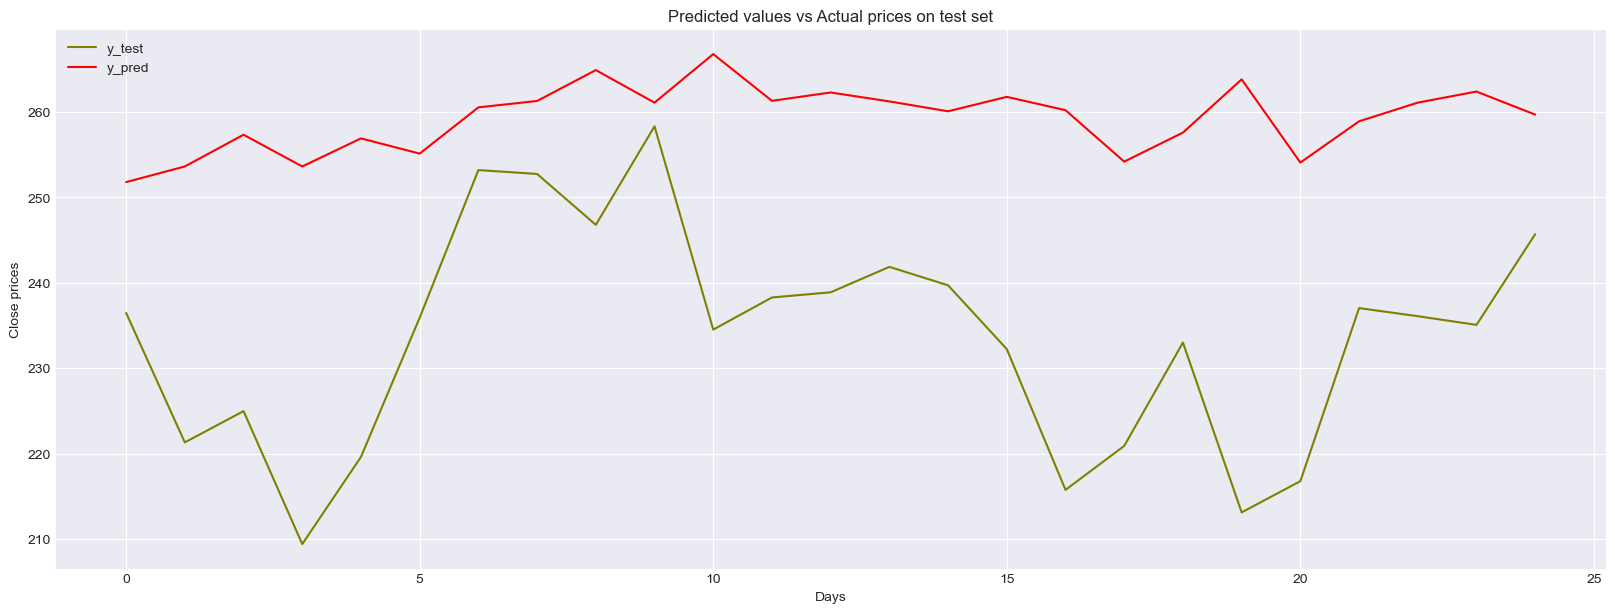

In [75]:
plt.figure(figsize=(20,7))
plt.plot(points, y_test, color='olive', label='y_test')
plt.plot(points, y_pred, color='red', label='y_pred')
plt.ylabel('Close prices')
plt.xlabel('Days') 
plt.title('Predicted values vs Actual prices on test set')
plt.legend(loc='upper left') 

#### Predicting values using x_test and creating signal

In [73]:
print(x_test_copy.shape) 
x_test_copy['price_prediction'] = model.predict(x_test_copy.loc[:,X_cols]) 

(67, 11)


In [74]:
x_test_copy['model_signal'] = np.where(x_test_copy['price_prediction']>x_test_copy['Close'],1,-1) 

### Defining Strategy and Compute the return

In [76]:
def compute_ret(df):
    df['ret'] = df.Close.shift(-1).pct_change()
    df['cum_ret'] = np.cumsum(df.ret)
    df['strategy_ret'] = df.ret * df.model_signal.shift(1)
    df['cum_strategy_ret'] = np.cumsum(df.strategy_ret)
    return df 

In [77]:
df2 = compute_ret(x_test_copy)

In [78]:
df2.head()

,Open,High,Low,Close,Adj Close,Volume,ema_short,ema_long,rsi,obv,tweet_sentiment,price_prediction,model_signal,ret,cum_ret,strategy_ret,cum_strategy_ret
Date,,,,,,,,,,,,,,,,,
2022-06-24,237.470001,246.066666,236.086670,245.706665,245.706665,95770800,233.665788,243.650488,51.749064,529807500.0,0.240741,263.233840,1,NaN,NaN,NaN,NaN
2022-06-27,249.366669,252.070007,242.566666,244.919998,244.919998,89178300,235.712008,243.732392,51.415963,440629200.0,0.391304,261.859510,1,-0.050044,-0.050044,-0.050044,-0.050044
2022-06-28,244.483337,249.970001,232.343338,232.663330,232.663330,90391200,235.157703,243.018259,46.404126,350238000.0,0.250000,261.191005,1,-0.017937,-0.067981,-0.017937,-0.067981
2022-06-29,230.500000,231.173340,222.273331,228.490005,228.490005,82897200,233.945394,242.080952,44.802734,267340800.0,0.350000,260.633835,1,-0.017579,-0.085560,-0.017579,-0.085560
2022-06-30,224.509995,229.456665,218.863327,224.473328,224.473328,94600500,232.223200,240.944976,43.255513,172740300.0,0.220779,261.843670,1,0.012429,-0.073131,0.012429,-0.073131


### Plot return of benchmark and strategy

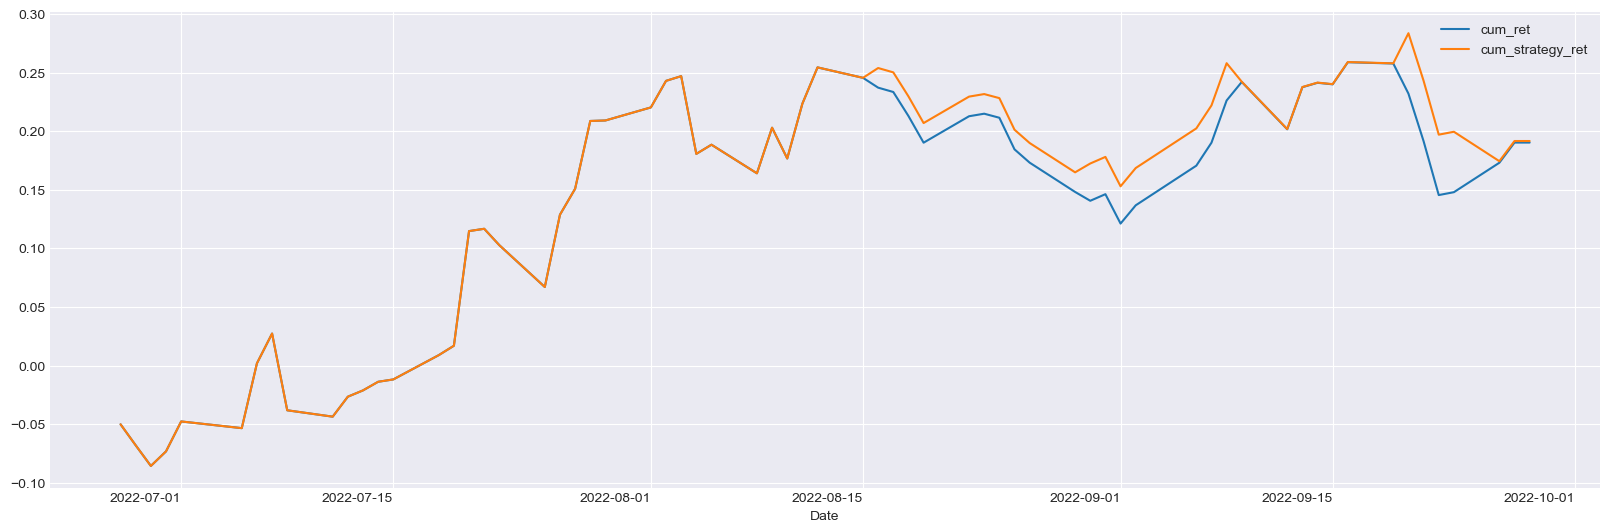

In [79]:
plt.figure(figsize=(20,7)) 
df2['cum_ret'].plot(figsize=(20,7))
df2['cum_strategy_ret'].plot(figsize=(20,7)) 
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show() 

#### Calculating Sharpe Ratio

In [80]:
def sharpe(df):
    sharpe_ratio = df.strategy_ret.mean()/df.strategy_ret.std()*np.sqrt(252)
    return sharpe_ratio

In [81]:
sharpe(df2) 

1.5454226455455782

In [82]:
print('Average cumulative return : ',df2['cum_ret'].mean())
print('Average strategic cumulative return : ',df2['cum_strategy_ret'].mean())

Average cumulative return :  0.13741628076801457
Average strategic cumulative return :  0.1465263961435433


In [83]:
df2.dropna(inplace=True) 
df2.head()  

,Open,High,Low,Close,Adj Close,Volume,ema_short,ema_long,rsi,obv,tweet_sentiment,price_prediction,model_signal,ret,cum_ret,strategy_ret,cum_strategy_ret
Date,,,,,,,,,,,,,,,,,
2022-06-27,249.366669,252.070007,242.566666,244.919998,244.919998,89178300,235.712008,243.732392,51.415963,440629200.0,0.391304,261.859510,1,-0.050044,-0.050044,-0.050044,-0.050044
2022-06-28,244.483337,249.970001,232.343338,232.663330,232.663330,90391200,235.157703,243.018259,46.404126,350238000.0,0.250000,261.191005,1,-0.017937,-0.067981,-0.017937,-0.067981
2022-06-29,230.500000,231.173340,222.273331,228.490005,228.490005,82897200,233.945394,242.080952,44.802734,267340800.0,0.350000,260.633835,1,-0.017579,-0.085560,-0.017579,-0.085560
2022-06-30,224.509995,229.456665,218.863327,224.473328,224.473328,94600500,232.223200,240.944976,43.255513,172740300.0,0.220779,261.843670,1,0.012429,-0.073131,0.012429,-0.073131
2022-07-01,227.000000,230.229996,222.119995,227.263336,227.263336,74460300,231.321407,240.062290,44.684466,247200600.0,0.315789,261.001505,1,0.025536,-0.047595,0.025536,-0.047595


In [84]:
df2.tail()

,Open,High,Low,Close,Adj Close,Volume,ema_short,ema_long,rsi,obv,tweet_sentiment,price_prediction,model_signal,ret,cum_ret,strategy_ret,cum_strategy_ret
Date,,,,,,,,,,,,,,,,,
2022-09-22,299.859985,301.290009,285.820007,288.589996,288.589996,70545400,298.214687,291.789110,47.344837,1.254410e+09,0.325301,292.227175,1,-0.045948,0.145525,-0.045948,0.197060
2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,294.053833,290.727231,40.570788,1.190662e+09,0.244186,272.049160,-1,0.002470,0.147995,0.002470,0.199530
2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,290.773138,289.777733,41.036720,1.248739e+09,0.430556,278.485155,1,0.025108,0.173103,-0.025108,0.174423
2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,289.348931,289.336589,45.708154,1.310664e+09,0.294118,278.454990,-1,0.017212,0.190315,0.017212,0.191635
2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,289.069125,289.238099,48.779261,1.365329e+09,0.373333,283.571655,-1,0.000000,0.190315,-0.000000,0.191635


In [85]:
l = len(df2) 
print('Cumulative returns start : ', df2['cum_ret'][0])
print('Cumulative returns end : ', df2['cum_ret'][l-1])
print('Strategy cumulative returns start : ', df2['cum_strategy_ret'][0])
print('Strategy cumulative returns end : ', df2['cum_strategy_ret'][l-1]) 

Cumulative returns start :  -0.0500435578248114
Cumulative returns end :  0.19031504052469383
Strategy cumulative returns start :  -0.0500435578248114
Strategy cumulative returns end :  0.19163461314156782


In [86]:
print(f"Percentage returns without strategy : {(df2['cum_ret'][l-1]-df2['cum_ret'][0])*100:.2f} %")  
print(f"Percentage returns with strategy : {(df2['cum_strategy_ret'][l-1]-df2['cum_strategy_ret'][0])*100:.2f}%")

Percentage returns without strategy : 24.04 %
Percentage returns with strategy : 24.17%
